In [1]:
import os
# 回到上一層資料夾
os.chdir('..')
# 打印當前工作目錄
print(os.getcwd())

d:\pythonProject\IC Lab\Gait_analysis\pyskl


In [2]:
b = !python -m colab.training_tools.train_stgcnpp_raw_3class_MT --data npz --pose yolo --view sagittal --feature j --frame 90 --epochs 300 --split 1 --run 1 --cls 3 

[[[1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.  ]
  [0.   1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.  ]
  [0.   0.   1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.  ]
  [0.   0.   0.   1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.  ]
  [0.   0.   0.   0.   1.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.  ]
  [0.   0.   0.   0.   0.   1.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.  ]
  [0.   0.   0.   0.   0.   0.   1.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.  ]
  [0.   0.   0.   0.   0.   0.   0.   1.   0.   0.   0.   0.   0.   0.
   0.   0.   0.  ]
  [0.   0.   0.   0.   0.   0.   0.   0.   1.   0.   0.   0.   0.   0.
   0.   0.   0.  ]
  [0.   0.   0.   0.   0.   0.   0.   0.   0.   1.   0.   0.   0.   0.
   0.   0.   0.  ]
  [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   1.   0.   0.   0.
   0.   0.   0.  ]
  [0.   0.

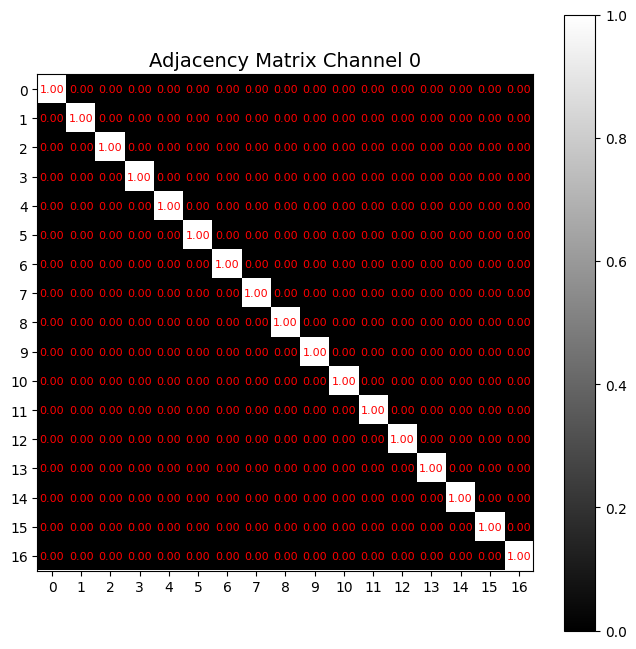

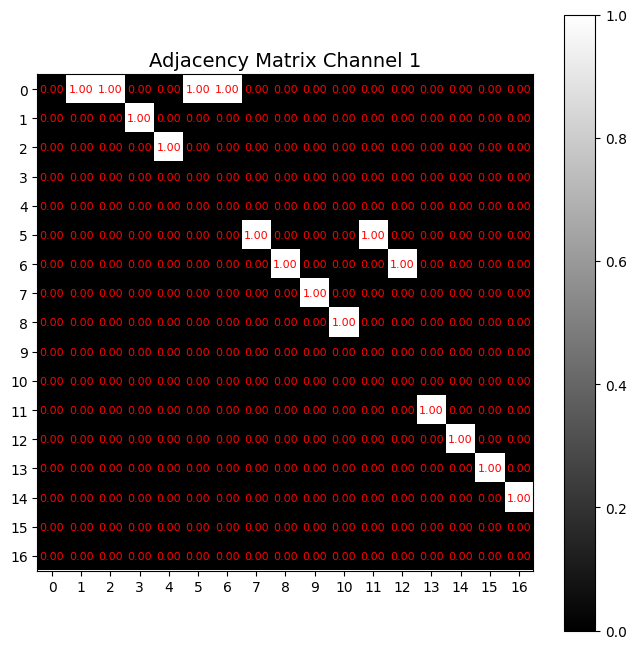

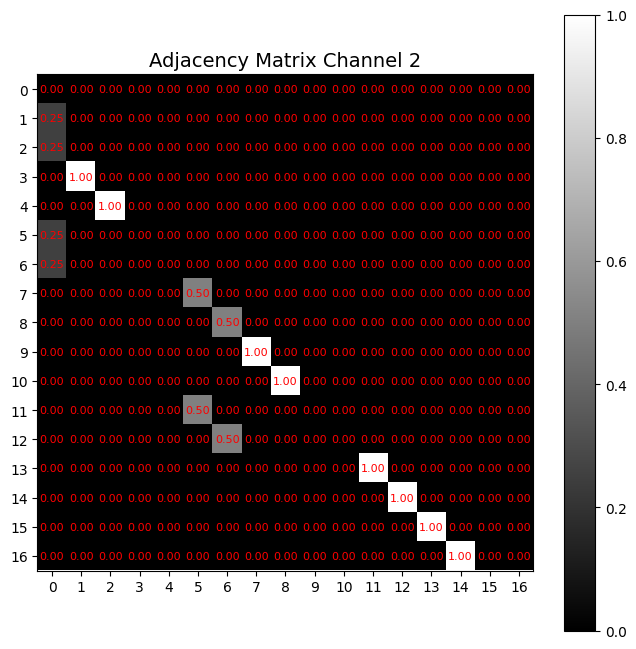

In [6]:
from colab.graph import Graph
import matplotlib.pyplot as plt

G = Graph(layout='coco',
      mode='spatial',
      max_hop=1,
      nx_node=1,
      num_filter=3,
      init_std=0.02,
      init_off=0.04)

print(G.A)
print(G.A.shape)

for i in range(3):
    plt.figure(figsize=(8, 8))
    plt.imshow(G.A[i], cmap='gray', vmin=0, vmax=1)
    plt.title(f'Adjacency Matrix Channel {i}', fontsize=14)
    plt.colorbar()
    
    # Add text annotations for each matrix element
    for row in range(G.A[i].shape[0]):
        for col in range(G.A[i].shape[1]):
            plt.text(col, row, f'{G.A[i][row, col]:.2f}',
                     ha='center', va='center', color='red', fontsize=8)
    
    plt.xticks(range(G.A[i].shape[1]))
    plt.yticks(range(G.A[i].shape[0]))
    plt.grid(False)
    plt.show()

In [29]:
from colab.models.stgcnpp import STGCN
import torch


model = STGCN(graph_cfg=dict(layout='coco', mode='spatial'),
                  in_channels=3,
                  base_channels=64,
                  data_bn_type='VC',
                  ch_ratio=2,  # 每次放大兩倍通道數
                  num_person=1,  # * Only used when data_bn_type == 'MVC'
                  num_stages=10,  # 有幾層
                  inflate_stages=[5, 8],  # 通道數在這兩層增加
                  down_stages=[5, 8],  # 時間維度下採樣，壓縮時間維度
                  pretrained=None,
                  tcn_type='mstcn',
                  tcn_dropout = 0,
                  gcn_with_res = True,
                  gcn_adaptive='init',
                  head_dropout=0,
                  num_classes=3)


state_dict = torch.load(r'D:\pythonProject\IC Lab\Gait_analysis\pyskl\pretrained\80c7d255012f41cd81bc92c83da17802.pt')
model.load_state_dict(state_dict)

<All keys matched successfully>


data_bn
gcn
gcn.0
gcn.0.gcn
gcn.0.gcn.bn
gcn.0.gcn.act
gcn.0.gcn.conv
gcn.0.gcn.down
gcn.0.gcn.down.0
gcn.0.gcn.down.1
gcn.0.tcn
gcn.0.tcn.act
gcn.0.tcn.branches
gcn.0.tcn.branches.0
gcn.0.tcn.branches.0.0
gcn.0.tcn.branches.0.1
gcn.0.tcn.branches.0.3
gcn.0.tcn.branches.0.3.conv
gcn.0.tcn.branches.0.3.bn
gcn.0.tcn.branches.0.3.drop
gcn.0.tcn.branches.1
gcn.0.tcn.branches.1.0
gcn.0.tcn.branches.1.1
gcn.0.tcn.branches.1.3
gcn.0.tcn.branches.1.3.conv
gcn.0.tcn.branches.1.3.bn
gcn.0.tcn.branches.1.3.drop
gcn.0.tcn.branches.2
gcn.0.tcn.branches.2.0
gcn.0.tcn.branches.2.1
gcn.0.tcn.branches.2.3
gcn.0.tcn.branches.2.3.conv
gcn.0.tcn.branches.2.3.bn
gcn.0.tcn.branches.2.3.drop
gcn.0.tcn.branches.3
gcn.0.tcn.branches.3.0
gcn.0.tcn.branches.3.1
gcn.0.tcn.branches.3.3
gcn.0.tcn.branches.3.3.conv
gcn.0.tcn.branches.3.3.bn
gcn.0.tcn.branches.3.3.drop
gcn.0.tcn.branches.4
gcn.0.tcn.branches.4.0
gcn.0.tcn.branches.4.1
gcn.0.tcn.branches.4.3
gcn.0.tcn.branches.5
gcn.0.tcn.transform
gcn.0.tcn.transfor

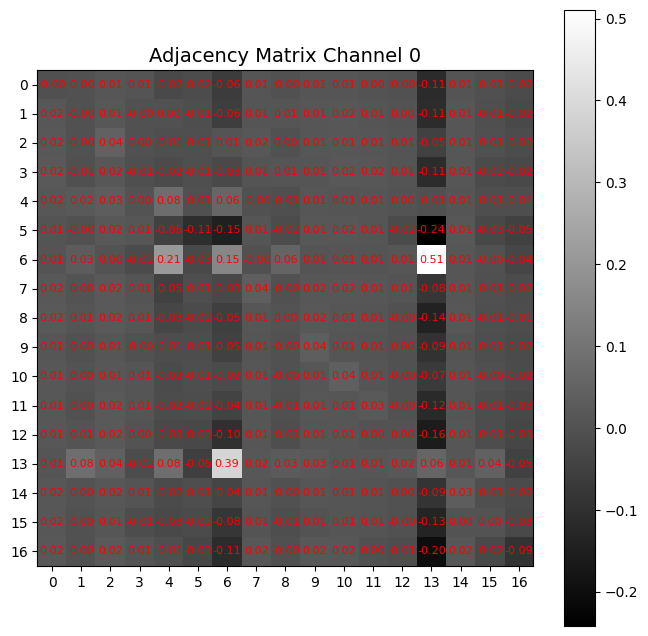

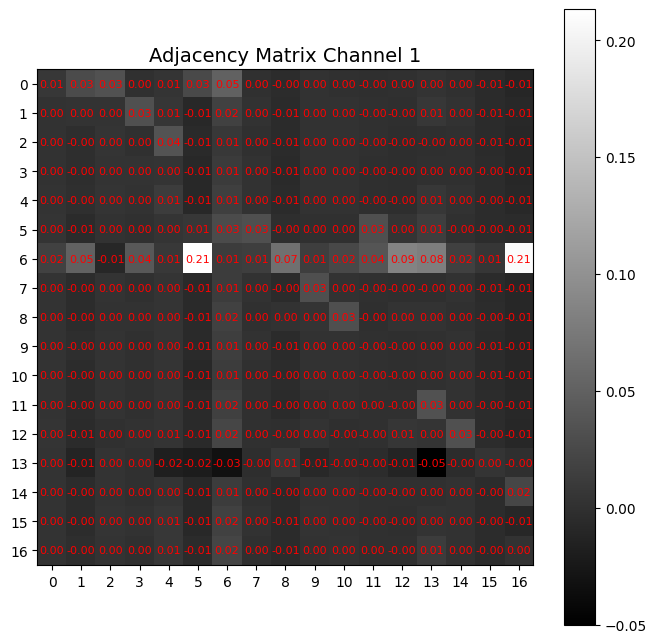

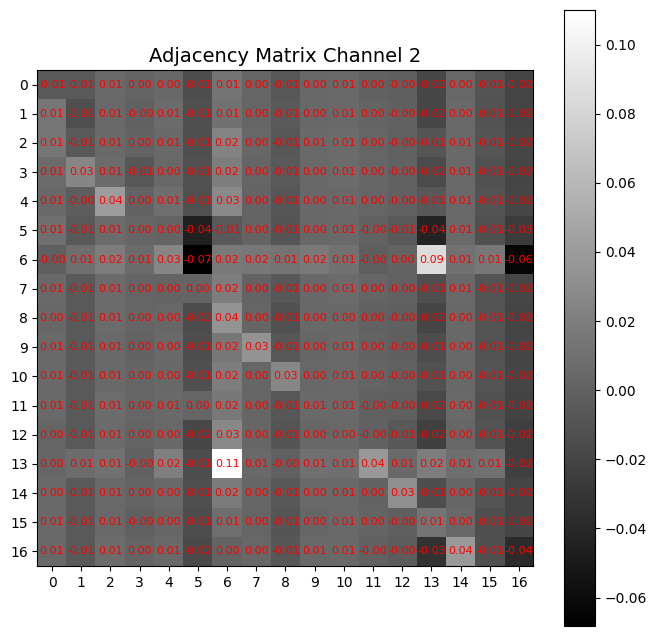

: 

In [30]:
# 確認模型結構
for name, module in model.named_modules():
    print(name)

# 假設你想檢查第0層的 GCN
gcn = model.gcn[9].gcn  # 假設模型是以這種結構設計的
# print("gcn[0] structure:", gcn)

# 確保 gcn.A 被正確轉換為 NumPy 格式
if hasattr(gcn, 'A'):
    A = gcn.A.detach().cpu().numpy()  # 確保轉換為 NumPy 數組

    for i in range(A.shape[0]):  # 遍歷每個通道
        vmin = A[i].min()  # 設置最小值
        vmax = A[i].max()  # 設置最大值

        plt.figure(figsize=(8, 8))
        plt.imshow(A[i], cmap='gray', vmin=vmin, vmax=vmax)
        plt.title(f'Adjacency Matrix Channel {i}', fontsize=14)
        plt.colorbar()

        # 添加文字標注到每個矩陣元素
        for row in range(A[i].shape[0]):
            for col in range(A[i].shape[1]):
                plt.text(col, row, f'{A[i][row, col]:.2f}',
                         ha='center', va='center', color='red', fontsize=8)

        plt.xticks(range(A[i].shape[1]))
        plt.yticks(range(A[i].shape[0]))
        plt.grid(False)
        plt.show()
else:
    print("gcn does not have attribute 'A'")


C:\Users\User\AppData\Local\Temp\ipykernel_23684\1824924090.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=height_data, x='性別', y='身高(cm)', palette=['#3498db', '#e67e22'], ax=axs[1, 0])
C:\Users\User\AppData\Local\Temp\ipykernel_23684\1824924090.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=weight_data, x='性別', y='體重(kg)', palette=['#3498db', '#e67e22'], ax=axs[1, 1])


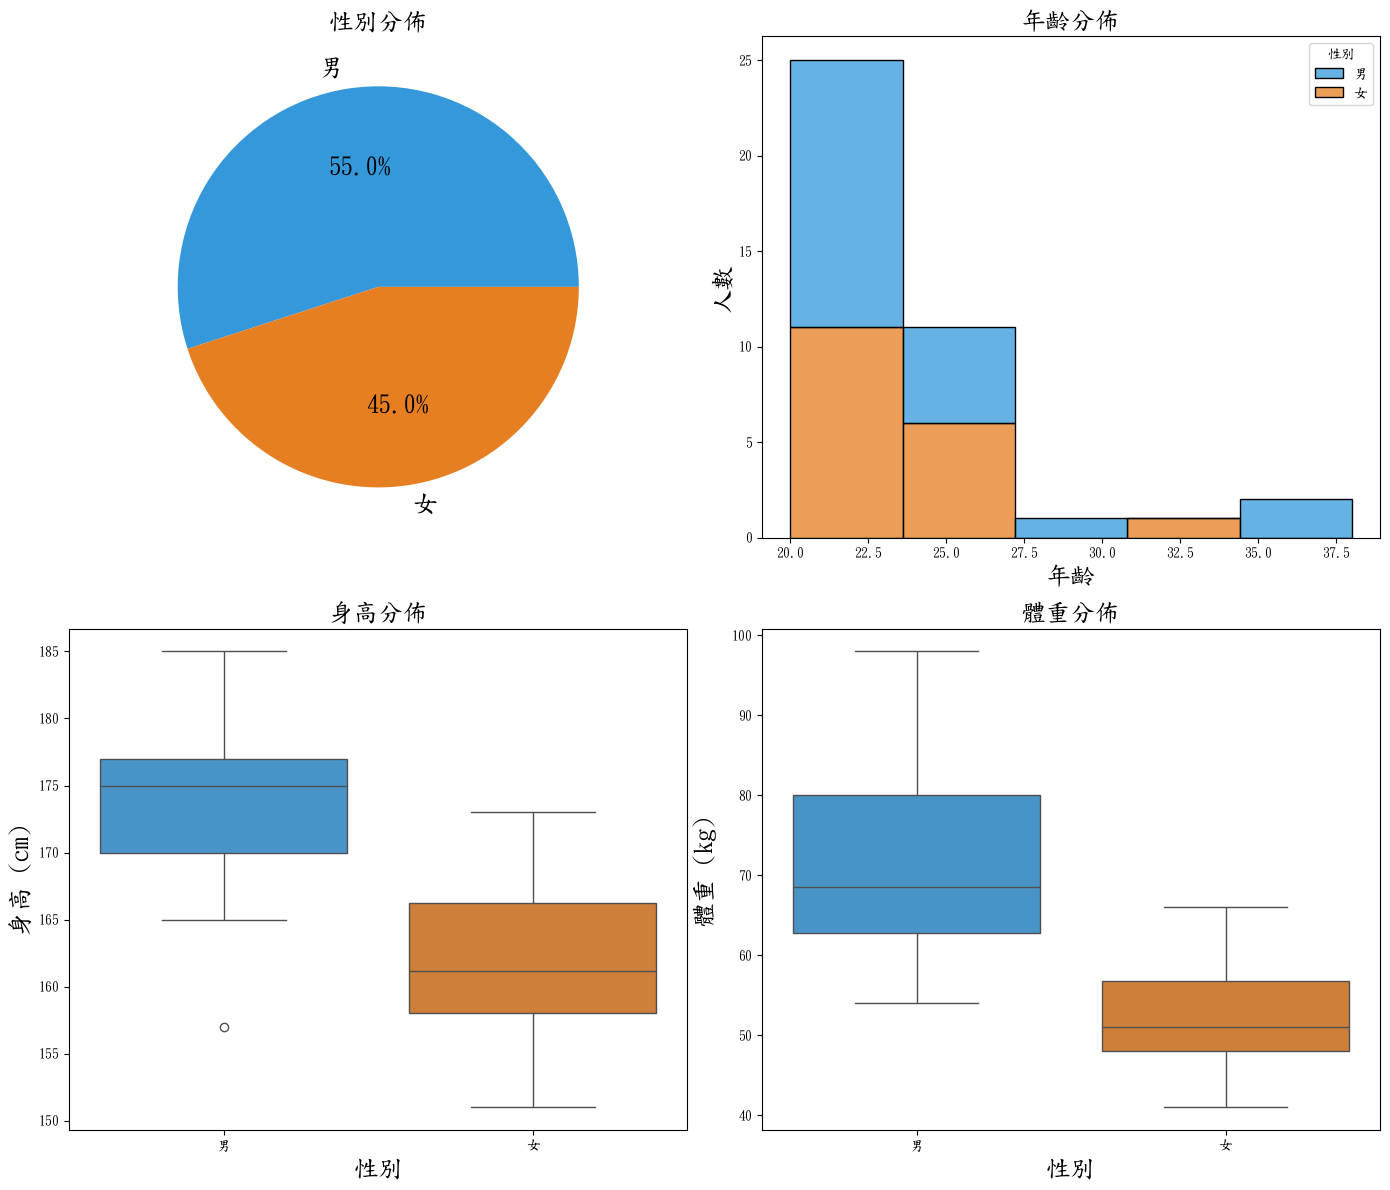

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rcParams

# 手動指定字體文件
font_path = r"C:\Windows\Fonts\kaiu.ttf"  # 替換為您系統中的中文字體文件路徑
font = font_manager.FontProperties(fname=font_path)
rcParams['font.sans-serif'] = font.get_name()  # 使用指定字體
rcParams['axes.unicode_minus'] = False  # 解決負號顯示問題

# Step 1: Load the data
file_path = r"C:\Users\User\Downloads\酒精步態資料集受試者資訊 (回覆).xlsx"  # 替換為您的文件路徑
df = pd.read_excel(file_path)

# Step 2: Prepare the data
gender_counts = df['性別'].value_counts()
height_data = df[['性別', '身高(cm)']]
weight_data = df[['性別', '體重(kg)']]

# Group ages into bins (e.g., starting from 20 to 40 with 5-year intervals)
df['年齡區間'] = pd.cut(df['年齡(歲)'], bins=range(20, 45, 5), right=False, labels=["20-25", "25-30", "30-35", "35-40"])

# Step 3: Create visualizations
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Gender distribution (pie chart)
axs[0, 0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
              colors=['#3498db', '#e67e22'], textprops={'fontsize': 18, 'fontproperties': font})
axs[0, 0].set_title('性別分佈', fontsize=18, fontproperties=font)

# Plot 2: Age distribution by gender (stacked histogram)
sns.histplot(data=df, x='年齡(歲)', hue='性別', multiple='stack',
             palette=['#3498db', '#e67e22'], ax=axs[0, 1], bins=5)
axs[0, 1].set_title('年齡分佈', fontsize=18, fontproperties=font)
axs[0, 1].set_xlabel('年齡', fontsize=18, fontproperties=font)
axs[0, 1].set_ylabel('人數', fontsize=18, fontproperties=font)

# Plot 3: Height distribution (box plot by gender)
sns.boxplot(data=height_data, x='性別', y='身高(cm)', palette=['#3498db', '#e67e22'], ax=axs[1, 0])
axs[1, 0].set_title('身高分佈', fontsize=18, fontproperties=font)
axs[1, 0].set_xlabel('性別', fontsize=18, fontproperties=font)
axs[1, 0].set_ylabel('身高 (cm)', fontsize=18, fontproperties=font)

# Plot 4: Weight distribution (box plot by gender)
sns.boxplot(data=weight_data, x='性別', y='體重(kg)', palette=['#3498db', '#e67e22'], ax=axs[1, 1])
axs[1, 1].set_title('體重分佈', fontsize=18, fontproperties=font)
axs[1, 1].set_xlabel('性別', fontsize=18, fontproperties=font)
axs[1, 1].set_ylabel('體重 (kg)', fontsize=18, fontproperties=font)

# Adjust layout
plt.tight_layout()
plt.show()


In [13]:
import os
os.chdir('..')

In [72]:
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset
import pandas as pd
import numpy as np
import glob

class Feeder(Dataset):
    def __init__(self, split=1, feature='j', phase='train'):
        self.csv_file = r'data\\PD-Walk\\datasets\\\CSVFolders\\hrnet_pd_norm_natural_forward_2_class_5_fold\\' + phase + '_' + str(split)+'.csv'
        self.data_root = r'data\\PD-Walk'
        self.labels = []
        self.data = []
        self.load_data()
        self.pose = 'coco'

        # 处理特征
        if 'b' in feature:
            self.data = self.calculate_bone(self.data)
        if 'm' in feature:
            self.data = self.calculate_motion(self.data)

    def get_bone_pairs(self):
        """根据 pose 类型返回骨骼连接对（不变）"""
        if self.pose == 'nturgb+d':
            return ((0, 1), (1, 20), (2, 20), (3, 2), (4, 20), (5, 4), (6, 5), (7, 6), (8, 20), (9, 8),
                    (10, 9), (11, 10), (12, 0), (13, 12), (14, 13), (15, 14), (16, 0), (17, 16), (18, 17),
                    (19, 18), (21, 22), (20, 20), (22, 7), (23, 24), (24, 11))
        elif self.pose == 'coco' or self.pose == 'blaze' or self.pose == 'yolo':
            return ((0, 0), (1, 0), (2, 0), (3, 1), (4, 2), (5, 0), (6, 0), (7, 5), (8, 6), (9, 7), (10, 8),
                    (11, 0), (12, 0), (13, 11), (14, 12), (15, 13), (16, 14))
        elif self.pose == 'openpose':
            return ((0, 0), (1, 0), (2, 1), (3, 2), (4, 3), (5, 1), (6, 5), (7, 6), (8, 2), (9, 8), (10, 9),
                    (11, 5), (12, 11), (13, 12), (14, 0), (15, 0), (16, 14), (17, 15))
        else:
            raise ValueError(f"Unsupported pose type: {self.pose}")

    def load_data(self):
        """載入所有數據和標籤"""
        # 讀取 CSV 文件
        if not os.path.exists(self.csv_file):
            raise FileNotFoundError(f"CSV file '{self.csv_file}' not found!")
        
        df = pd.read_csv(self.csv_file, header=None, names=['path', 'label'])

        # 檢查 CSV 是否包含必要的欄位
        if 'path' not in df.columns or 'label' not in df.columns:
            raise ValueError("CSV file must contain 'path' and 'label' columns!")
        
        # 遍歷每一行
        for index, row in df.iterrows():
            dir_path = row['path']  # 第一列：目錄路徑
            label = int(row['label'])  # 第二列：標籤，轉為整數
            
            # 構建完整的目錄路徑
            full_dir_path = os.path.join(self.data_root, dir_path)
            
            # 遍歷目錄下所有的 .npz 文件
            npy_files = glob.glob(os.path.join(full_dir_path, "*.npy"))
            if not npy_files:
                # print(f"Warning: No .npz files found in directory '{full_dir_path}'! Skipping...")
                continue
            
            for npy_path in npy_files:
                # 載入 .npy 文件
                try:
                    # 直接載入 .npy 文件，它是一個單個 numpy 陣列
                    data = np.load(npy_path)
                    
                    # 添加到數據列表
                    self.data.append(data)
                    self.labels.append(label)
                    
                    # print(f"Loaded: {npy_path} | Label: {label} | Shape: {data.shape}")
                except Exception as e:
                    # print(f"Error loading {npy_path}: {str(e)}")
                    continue

        self.data = np.array(self.data) # N T V C
        self.labels = np.array(self.labels) 
        N, T, V, C = self.data.shape
        self.data = self.data.reshape(N, 1, T, V, C)
        
        # print(f"\nTotal loaded samples: {len(self.data)}")
    
    def __len__(self):
        """ 返回數據集大小 """
        return len(self.data)
    
    def calculate_bone(self, keypoints):
        """計算骨骼特徵（不變）"""
        N, M, T, V, C = keypoints.shape
        bone = np.zeros_like(keypoints, dtype=np.float32)

        for v1, v2 in self.bone_pairs:
            bone[..., v1, :] = keypoints[..., v1, :] - keypoints[..., v2, :]
            if C >= 3 and self.pose in ['openpose', 'coco', 'blaze', 'yolo']:
                score = (keypoints[..., v1, 2] + keypoints[..., v2, 2]) / 2
                bone[..., v1, 2] = score
            if C == 4 and self.pose == 'blaze':
                score = (keypoints[..., v1, 3] + keypoints[..., v2, 3]) / 2
                bone[..., v1, 3] = score
        return bone

    def calculate_motion(self, keypoints):
        """計算運動特徵（不變）"""
        N, M, T, V, C = keypoints.shape
        motion = np.zeros_like(keypoints, dtype=np.float32)
        diff = np.diff(keypoints, axis=2)
        motion[:, :, :T-1] = diff
        if C >= 3 and self.pose in ['openpose', 'coco', 'blaze', 'yolo']:
            score = (keypoints[:, :, 1:, :, 2] + keypoints[:, :, :T - 1, :, 2]) / 2
            motion[:, :, :T - 1, :, 2] = score
        if C == 4 and self.pose == 'blaze':
            score = (keypoints[:, :, 1:, :, 3] + keypoints[:, :, :T - 1, :, 3]) / 2
            motion[:, :, :T - 1, :, 3] = score
        return motion

    
    def __getitem__(self, idx):
        return {
            'keypoint': torch.tensor(self.data[idx], dtype=torch.float32),
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
            'name': self.names[idx]
        }
    


In [76]:
def load_dataset(split=1, feature='j'):
    train_dataset = Feeder(split=1, feature='j', phase='train')
    test_val_dataset = Feeder(split=1, feature='j', phase='test')
    test_size = len(test_val_dataset)

    val_size = int(0.4 * test_size)
    test_size_new = test_size - val_size

    np.random.seed(42)  # 固定種子
    indices = np.random.permutation(test_size)

    val_indices = indices[:val_size]
    test_indices = indices[val_size:]

    val_dataset = Subset(test_val_dataset, val_indices)
    test_dataset = Subset(test_val_dataset, test_indices)

    return train_dataset, val_dataset, test_dataset

for split in [1, 3]:
    print(split)
    tra, val, tes = load_dataset(1, 'bm')
    print(len(tra), len(val), len(tes))
    

1
7478 957 1437
3
7478 957 1437
